# Unified Control Demonstrations


This notebook demonstrates the behaviour of several controllers acting on shared plants, using the `unified_control.py` module:

1. Linear PCT vs Active Inference on the same plant
2. Divergence on a nonlinear plant
3. Hierarchical PCT control
4. Sparse narrative controller
5. Sheaf-style consistency diagnostics


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import unified_control as uc

## 1. Linear plant: PCT vs Active Inference

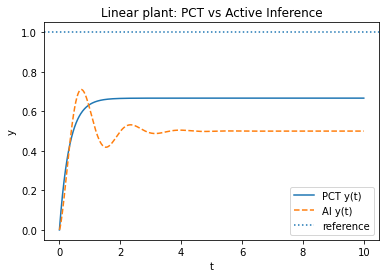

In [7]:

# Define a simple 1D plant: x' = -a x + b u, y = x
a = 1.0
b = 1.0
A = np.array([[-a]])
B = np.array([[b]])
C = np.array([[1.0]])

plant = uc.LinearPlant(A=A, B=B, C=C, process_noise_std=0.0, obs_noise_std=0.0)

# PCT controller: u = k_p (r - y)
k_p = 2.0
r = np.array([1.0])
pct = uc.PCTController(K=np.array([[k_p]]), reference=r)

# Active inference controller parameters
C_ai = C.copy()
Sigma_s_inv = np.array([[1.0]])
Sigma_o_inv = np.array([[4.0]])
B_a = np.array([[1.0]])

ai = uc.ActiveInferenceController(
    C=C_ai,
    Sigma_s_inv=Sigma_s_inv,
    Sigma_o_inv=Sigma_o_inv,
    B_a=B_a,
    mu=np.array([0.0]),
    a=np.array([0.0]),
    eta_mu=0.1,
    eta_a=0.1,
    preference_o=r.copy()
)

x0 = np.array([0.0])
t0, t1, dt = 0.0, 10.0, 0.01

res_pct = uc.simulate_pct_closed_loop(plant, pct, x0, t0, t1, dt)
res_ai = uc.simulate_active_inference_closed_loop(plant, ai, x0, t0, t1, dt)

plt.figure()
plt.plot(res_pct['t'], res_pct['y'][:, 0], label='PCT y(t)')
plt.plot(res_ai['t'], res_ai['y'][:, 0], linestyle='--', label='AI y(t)')
plt.axhline(r[0], linestyle=':', label='reference')
plt.xlabel('t')
plt.ylabel('y')
plt.legend()
plt.title('Linear plant: PCT vs Active Inference')
plt.show()


## 2. Nonlinear plant divergence example

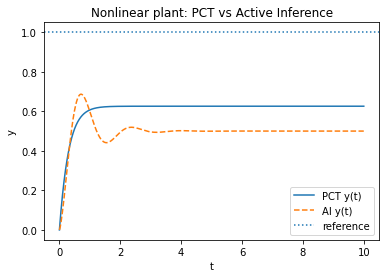

In [8]:

# Nonlinear plant with cubic term
alpha = 0.5
nonlin_plant = uc.NonlinearPlant(A=A, B=B, C=C, alpha=alpha, process_noise_std=0.0, obs_noise_std=0.0)

# Re-initialise controllers
pct2 = uc.PCTController(K=np.array([[k_p]]), reference=r)
ai2 = uc.ActiveInferenceController(
    C=C_ai,
    Sigma_s_inv=Sigma_s_inv,
    Sigma_o_inv=Sigma_o_inv,
    B_a=B_a,
    mu=np.array([0.0]),
    a=np.array([0.0]),
    eta_mu=0.1,
    eta_a=0.1,
    preference_o=r.copy()
)

def simulate_pct_nonlinear(plant, controller, x0, t0, t1, dt):
    n_steps = int(np.ceil((t1 - t0) / dt)) + 1
    ts = np.linspace(t0, t0 + dt * (n_steps - 1), n_steps)
    xs = np.zeros((n_steps, x0.size))
    ys = np.zeros((n_steps, 1))
    us = np.zeros((n_steps, 1))
    x = x0.copy()
    y = plant.C @ x
    for i, t in enumerate(ts):
        xs[i] = x
        ys[i] = y
        u = controller.act(y)
        us[i] = u
        x, y = plant.step(x, u, dt)
    return ts, xs, ys, us

def simulate_ai_nonlinear(plant, controller, x0, t0, t1, dt):
    n_steps = int(np.ceil((t1 - t0) / dt)) + 1
    ts = np.linspace(t0, t0 + dt * (n_steps - 1), n_steps)
    xs = np.zeros((n_steps, x0.size))
    ys = np.zeros((n_steps, 1))
    us = np.zeros((n_steps, 1))
    mus = np.zeros((n_steps, controller.mu.size))
    x = x0.copy()
    y = plant.C @ x
    for i, t in enumerate(ts):
        xs[i] = x
        ys[i] = y
        mus[i] = controller.mu
        u = controller.update(y)
        us[i] = u
        x, y = plant.step(x, u, dt)
    return ts, xs, ys, us, mus

res_pct2 = simulate_pct_nonlinear(nonlin_plant, pct2, x0, t0, t1, dt)
res_ai2 = simulate_ai_nonlinear(nonlin_plant, ai2, x0, t0, t1, dt)

ts = res_pct2[0]
plt.figure()
plt.plot(ts, res_pct2[2][:, 0], label='PCT y(t)')
plt.plot(ts, res_ai2[2][:, 0], linestyle='--', label='AI y(t)')
plt.axhline(r[0], linestyle=':', label='reference')
plt.xlabel('t')
plt.ylabel('y')
plt.legend()
plt.title('Nonlinear plant: PCT vs Active Inference')
plt.show()


## 3. Hierarchical PCT control (two levels)

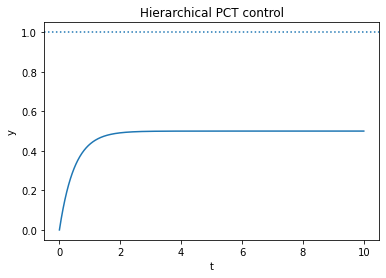

In [9]:

# Simple demonstration: high-level controller sets reference for low-level

class TwoLevelPCT:
    def __init__(self, K_high, K_low, r_high):
        self.K_high = K_high  # reference to "meaning" variable
        self.K_low = K_low    # motor gain
        self.r_high = r_high  # desired percept at high level
        self.y_high = 0.0     # current high-level percept

    def act(self, y_low):
        # high-level percept = low-level y (identity for demo)
        self.y_high = y_low
        e_high = self.r_high - self.y_high
        # high-level output is new reference for low-level
        r_low = self.K_high * e_high + self.y_high
        e_low = r_low - y_low
        u = self.K_low * e_low
        return u

# Wrap TwoLevelPCT for use with LinearPlant
class WrappedTwoLevel:
    def __init__(self, ctl):
        self.ctl = ctl
    def act(self, y):
        u = self.ctl.act(y[0])
        return np.array([u])

two_level_ctl = TwoLevelPCT(K_high=0.5, K_low=2.0, r_high=1.0)
wrapped_ctl = WrappedTwoLevel(two_level_ctl)

# Simulate
n_steps = int((t1 - t0) / dt) + 1
ts = np.linspace(t0, t0 + dt * (n_steps - 1), n_steps)
xs = np.zeros((n_steps, 1))
ys = np.zeros((n_steps, 1))
us = np.zeros((n_steps, 1))
x = x0.copy()
y = plant.C @ x
for i, t in enumerate(ts):
    xs[i] = x
    ys[i] = y
    u = wrapped_ctl.act(y)
    us[i] = u
    x, y = plant.step(x, u, dt)

plt.figure()
plt.plot(ts, ys[:, 0])
plt.axhline(1.0, linestyle=':')
plt.xlabel('t')
plt.ylabel('y')
plt.title('Hierarchical PCT control')
plt.show()


## 4. Sparse narrative controller

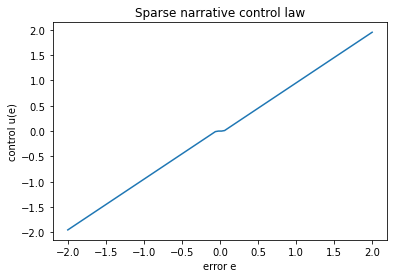

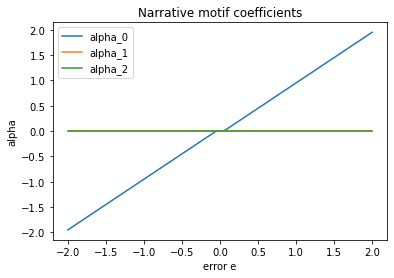

In [10]:

# Toy example: three narrative motifs for error correction
D = np.array([[1.0, -1.0, 0.5]]).T  # shape (3,1) would be awkward; use 1D error, 3 motifs
D = D.reshape(1, 3)
W = np.array([[1.0, -0.5, 0.5]])  # control mapping

sparse_ctl = uc.SparseNarrativeController(D=D, W=W, lam=0.05, n_iter=20)

errors = np.linspace(-2.0, 2.0, 100)
controls = []
alphas = []
for e in errors:
    alpha = sparse_ctl.infer_alpha(np.array([e]))
    u = W @ alpha
    controls.append(u[0])
    alphas.append(alpha)

controls = np.array(controls)
alphas = np.array(alphas)

plt.figure()
plt.plot(errors, controls)
plt.xlabel('error e')
plt.ylabel('control u(e)')
plt.title('Sparse narrative control law')
plt.show()

plt.figure()
for j in range(alphas.shape[1]):
    plt.plot(errors, alphas[:, j], label=f'alpha_{j}')
plt.xlabel('error e')
plt.ylabel('alpha')
plt.title('Narrative motif coefficients')
plt.legend()
plt.show()


## 5. Sheaf-style consistency diagnostics

In [11]:

# Two contexts over 3 variables: v0, v1, v2
c1 = uc.SheafContext(name='context1', vars=[0, 1], x_local=np.array([1.0, 0.0]))
c2 = uc.SheafContext(name='context2', vars=[1, 2], x_local=np.array([0.2, -1.0]))
c3 = uc.SheafContext(name='context3', vars=[0, 2], x_local=np.array([1.2, -0.5]))

diag = uc.SheafDiagnostic(contexts=[c1, c2, c3])
disc = diag.overlap_discrepancies()
score = diag.global_conflict_score()

print('Overlap discrepancies:')
for (i, j), d in disc.items():
    print(f'contexts {i}-{j}: {d:.3f}')

print(f'Global conflict score: {score:.3f}')


Overlap discrepancies:
contexts 0-1: 0.200
contexts 0-2: 0.200
contexts 1-2: 0.500
Global conflict score: 0.300
